In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow_datasets as tfds

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## TensorFlow augmentation 7 methods 

In [2]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)


# Model
def build_cnn(input_shape, num_classes, onehot=False):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])

    loss = "categorical_crossentropy" if onehot else "sparse_categorical_crossentropy"
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss,
        metrics=["accuracy"]
    )
    return model


# Common augmentation layers (create once)
rot = tf.keras.layers.RandomRotation(0.08)
trans = tf.keras.layers.RandomTranslation(0.08, 0.08)
zm = tf.keras.layers.RandomZoom(0.10)
con = tf.keras.layers.RandomContrast(0.10)


# 8 methods (0~7)
def method0(x, y):
    return x, y

def method1(x, y):
    x = rot(x, training=True)
    return x, y

def method2(x, y):
    x = trans(x, training=True)
    return x, y

def method3(x, y):
    x = zm(x, training=True)
    return x, y

def method4(x, y, is_rgb):
    x = rot(x, training=True)
    x = trans(x, training=True)
    x = zm(x, training=True)
    if is_rgb:
        x = con(x, training=True)
    return x, y

# Method 5: MixUp (one-hot y)
def method5(x, y, num_classes):
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)

    batch_size = tf.shape(x)[0]
    alpha = 0.2

    a = tf.random.gamma([batch_size], alpha)
    b = tf.random.gamma([batch_size], alpha)
    lam = a / (a + b + 1e-8)

    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])

    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    x = x * lam_x + x2 * (1.0 - lam_x)
    y = y * lam_y + y2 * (1.0 - lam_y)
    return x, y

# Method 6: CutMix (one-hot y, simple batch-wise)
def method6(x, y, num_classes):
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)

    batch_size = tf.shape(x)[0]
    height = tf.shape(x)[1]
    width = tf.shape(x)[2]
    channels = tf.shape(x)[3]

    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    alpha = 1.0
    a = tf.random.gamma([], alpha)
    b = tf.random.gamma([], alpha)
    lam = a / (a + b + 1e-8)

    cut_ratio = tf.sqrt(1.0 - lam)
    cut_w = tf.cast(tf.cast(width, tf.float32) * cut_ratio, tf.int32)
    cut_h = tf.cast(tf.cast(height, tf.float32) * cut_ratio, tf.int32)

    cx = tf.random.uniform([], 0, width, dtype=tf.int32)
    cy = tf.random.uniform([], 0, height, dtype=tf.int32)

    x1 = tf.clip_by_value(cx - cut_w // 2, 0, width)
    x2b = tf.clip_by_value(cx + cut_w // 2, 0, width)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, height)
    y2b = tf.clip_by_value(cy + cut_h // 2, 0, height)

    xs = tf.range(width)[None, :]
    ys = tf.range(height)[:, None]
    inside = tf.logical_and(
        tf.logical_and(xs >= x1, xs < x2b),
        tf.logical_and(ys >= y1, ys < y2b)
    )

    mask = tf.cast(inside, tf.float32)[None, ..., None]
    mask = tf.broadcast_to(mask, [batch_size, height, width, channels])

    x = x * (1.0 - mask) + x2 * mask

    area = tf.cast((x2b - x1) * (y2b - y1), tf.float32)
    lam_real = 1.0 - area / (tf.cast(height * width, tf.float32) + 1e-8)
    y = y * lam_real + y2 * (1.0 - lam_real)

    return x, y

# Method 7: RandAugment (built-in)
randaugment = tf.keras.layers.RandAugment(
    value_range=(0.0, 1.0),
    num_ops=2,
    factor=0.5
)

def method7(x, y, is_rgb):
    if not is_rgb:
        # 1-channel -> 3-channel
        x = tf.concat([x, x, x], axis=-1)

        # RandAugment needs 3 channels
        x = randaugment(x, training=True)

        # 3-channel -> 1-channel
        x = tf.reduce_mean(x, axis=-1, keepdims=True)
    else:
        x = randaugment(x, training=True)

    return x, y





# Train each method
def run_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    use_onehot = (method_id == 5 or method_id == 6)
    model = build_cnn(input_shape, num_classes, onehot=use_onehot)

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    methods = [method0, method1, method2, method3, method4, method5, method6, method7]

    def train_map(x, y):
        for i in range(len(methods)):
            if i == method_id:
                if i == 4:
                    return methods[i](x, y, is_rgb)
                elif i in [5, 6]:
                    return methods[i](x, y, num_classes)
                elif i == 7:
                    return methods[i](x, y, is_rgb) 
                else:
                    return methods[i](x, y)


    train_ds = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

    if use_onehot:
        def val_map(x, y):
            y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)
            return x, y
        val_ds = val_ds.map(val_map, num_parallel_calls=tf.data.AUTOTUNE)

    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc



# Plot
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_final_summary(results_dict, title="Final Train / Val Accuracy by Method"):
    methods = sorted(results_dict.keys())
    train_acc = [results_dict[m][0] for m in methods]
    val_acc = [results_dict[m][1] for m in methods]

    plt.figure(figsize=(8, 5))
    plt.plot(methods, train_acc, marker="o", label="Train Accuracy")
    plt.plot(methods, val_acc, marker="s", label="Validation Accuracy")

    plt.xticks(methods)
    plt.xlabel("Method ID")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

##  SVHN



SVHN - Method 0
-----------------
Epoch 1/20
1242/1242 - 9s - 7ms/step - accuracy: 0.7424 - loss: 0.8528 - val_accuracy: 0.8392 - val_loss: 0.5725
Epoch 2/20
1242/1242 - 7s - 6ms/step - accuracy: 0.8655 - loss: 0.4817 - val_accuracy: 0.8743 - val_loss: 0.4512
Epoch 3/20
1242/1242 - 7s - 6ms/step - accuracy: 0.8845 - loss: 0.4036 - val_accuracy: 0.8839 - val_loss: 0.4144
Epoch 4/20
1242/1242 - 7s - 6ms/step - accuracy: 0.8993 - loss: 0.3533 - val_accuracy: 0.8880 - val_loss: 0.3950
Epoch 5/20
1242/1242 - 7s - 6ms/step - accuracy: 0.9095 - loss: 0.3141 - val_accuracy: 0.8988 - val_loss: 0.3604
Epoch 6/20
1242/1242 - 7s - 6ms/step - accuracy: 0.9176 - loss: 0.2836 - val_accuracy: 0.8990 - val_loss: 0.3682
Epoch 7/20
1242/1242 - 8s - 6ms/step - accuracy: 0.9254 - loss: 0.2566 - val_accuracy: 0.9017 - val_loss: 0.3566
Epoch 8/20
1242/1242 - 8s - 6ms/step - accuracy: 0.9333 - loss: 0.2295 - val_accuracy: 0.9035 - val_loss: 0.3586
Epoch 9/20
1242/1242 - 9s - 7ms/step - accuracy: 0.9401 - lo

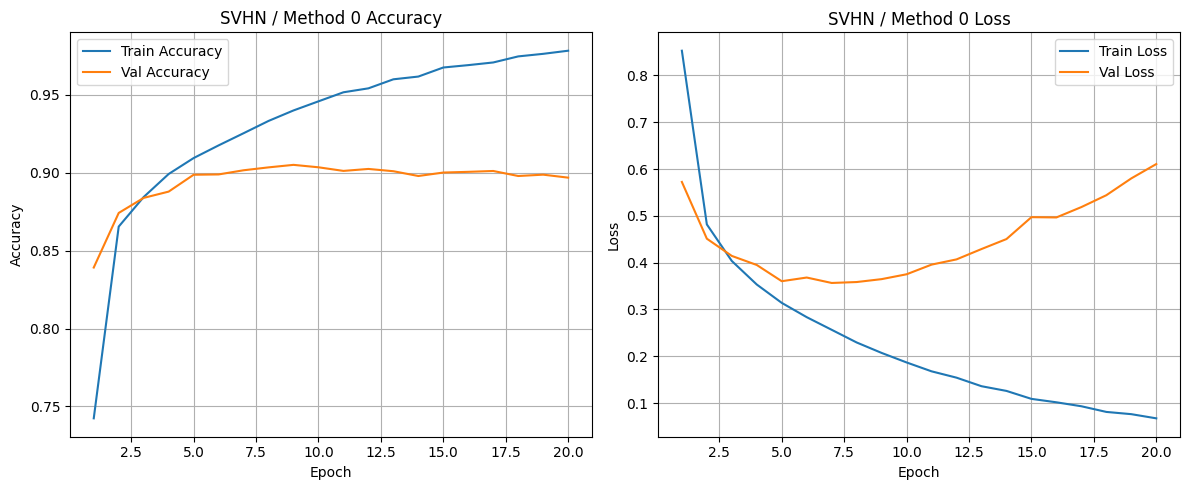



SVHN - Method 1
-----------------
Epoch 1/20
1242/1242 - 10s - 8ms/step - accuracy: 0.6393 - loss: 1.1379 - val_accuracy: 0.8038 - val_loss: 0.6835
Epoch 2/20
1242/1242 - 8s - 6ms/step - accuracy: 0.8043 - loss: 0.6757 - val_accuracy: 0.8429 - val_loss: 0.5486
Epoch 3/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8345 - loss: 0.5686 - val_accuracy: 0.8581 - val_loss: 0.4808
Epoch 4/20
1242/1242 - 9s - 7ms/step - accuracy: 0.8492 - loss: 0.5084 - val_accuracy: 0.8580 - val_loss: 0.4715
Epoch 5/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8592 - loss: 0.4729 - val_accuracy: 0.8782 - val_loss: 0.4253
Epoch 6/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8690 - loss: 0.4426 - val_accuracy: 0.8801 - val_loss: 0.4141
Epoch 7/20
1242/1242 - 10s - 8ms/step - accuracy: 0.8755 - loss: 0.4197 - val_accuracy: 0.8849 - val_loss: 0.3992
Epoch 8/20
1242/1242 - 9s - 7ms/step - accuracy: 0.8818 - loss: 0.3999 - val_accuracy: 0.8869 - val_loss: 0.3905
Epoch 9/20
1242/1242 - 10s - 8ms/step - accuracy: 0.8847 -

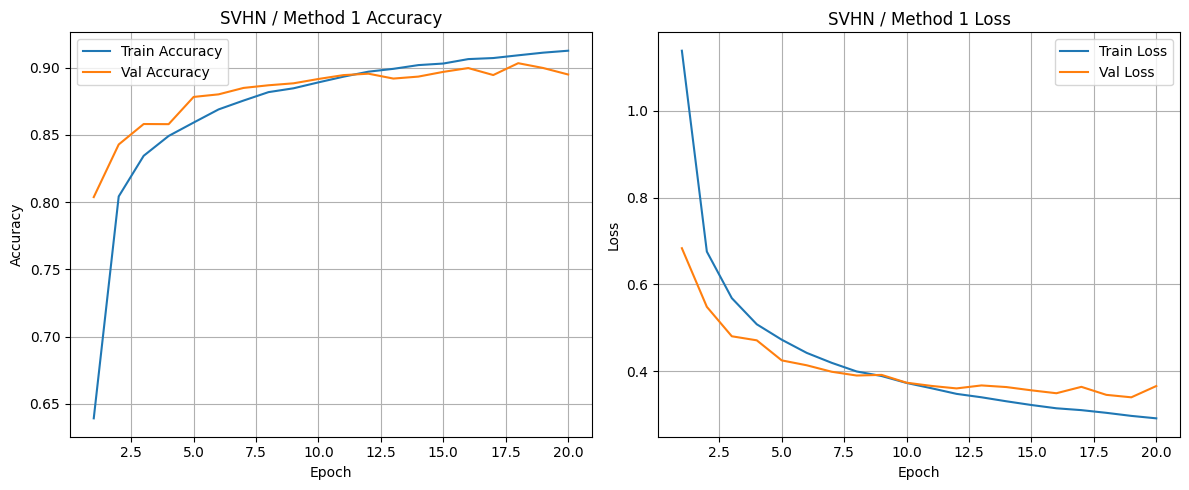



SVHN - Method 2
-----------------
Epoch 1/20
1242/1242 - 10s - 8ms/step - accuracy: 0.6711 - loss: 1.0544 - val_accuracy: 0.8308 - val_loss: 0.5830
Epoch 2/20
1242/1242 - 8s - 6ms/step - accuracy: 0.8141 - loss: 0.6420 - val_accuracy: 0.8746 - val_loss: 0.4430
Epoch 3/20
1242/1242 - 9s - 7ms/step - accuracy: 0.8439 - loss: 0.5305 - val_accuracy: 0.8831 - val_loss: 0.4114
Epoch 4/20
1242/1242 - 8s - 6ms/step - accuracy: 0.8578 - loss: 0.4761 - val_accuracy: 0.8946 - val_loss: 0.3706
Epoch 5/20
1242/1242 - 8s - 6ms/step - accuracy: 0.8714 - loss: 0.4341 - val_accuracy: 0.8959 - val_loss: 0.3587
Epoch 6/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8807 - loss: 0.4031 - val_accuracy: 0.9051 - val_loss: 0.3365
Epoch 7/20
1242/1242 - 9s - 7ms/step - accuracy: 0.8880 - loss: 0.3798 - val_accuracy: 0.9016 - val_loss: 0.3406
Epoch 8/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8920 - loss: 0.3654 - val_accuracy: 0.9126 - val_loss: 0.3022
Epoch 9/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8979 - l

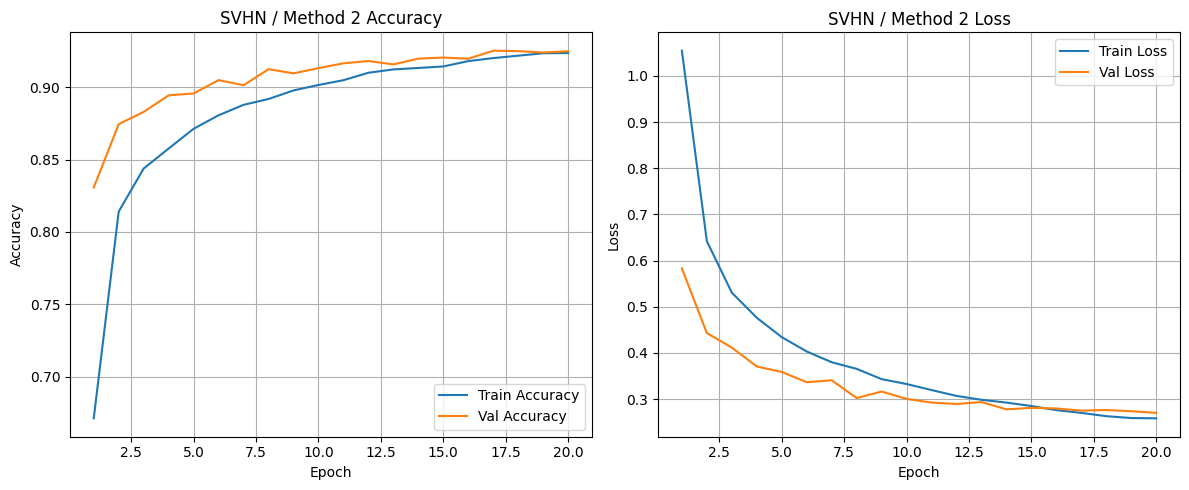



SVHN - Method 3
-----------------
Epoch 1/20
1242/1242 - 9s - 8ms/step - accuracy: 0.7208 - loss: 0.9169 - val_accuracy: 0.8360 - val_loss: 0.5810
Epoch 2/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8557 - loss: 0.5177 - val_accuracy: 0.8711 - val_loss: 0.4670
Epoch 3/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8768 - loss: 0.4303 - val_accuracy: 0.8833 - val_loss: 0.4105
Epoch 4/20
1242/1242 - 9s - 7ms/step - accuracy: 0.8902 - loss: 0.3799 - val_accuracy: 0.8900 - val_loss: 0.3806
Epoch 5/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8986 - loss: 0.3453 - val_accuracy: 0.8941 - val_loss: 0.3720
Epoch 6/20
1242/1242 - 9s - 7ms/step - accuracy: 0.9068 - loss: 0.3191 - val_accuracy: 0.8975 - val_loss: 0.3623
Epoch 7/20
1242/1242 - 8s - 7ms/step - accuracy: 0.9127 - loss: 0.2959 - val_accuracy: 0.9019 - val_loss: 0.3460
Epoch 8/20
1242/1242 - 8s - 7ms/step - accuracy: 0.9198 - loss: 0.2761 - val_accuracy: 0.9013 - val_loss: 0.3506
Epoch 9/20
1242/1242 - 8s - 6ms/step - accuracy: 0.9233 - lo

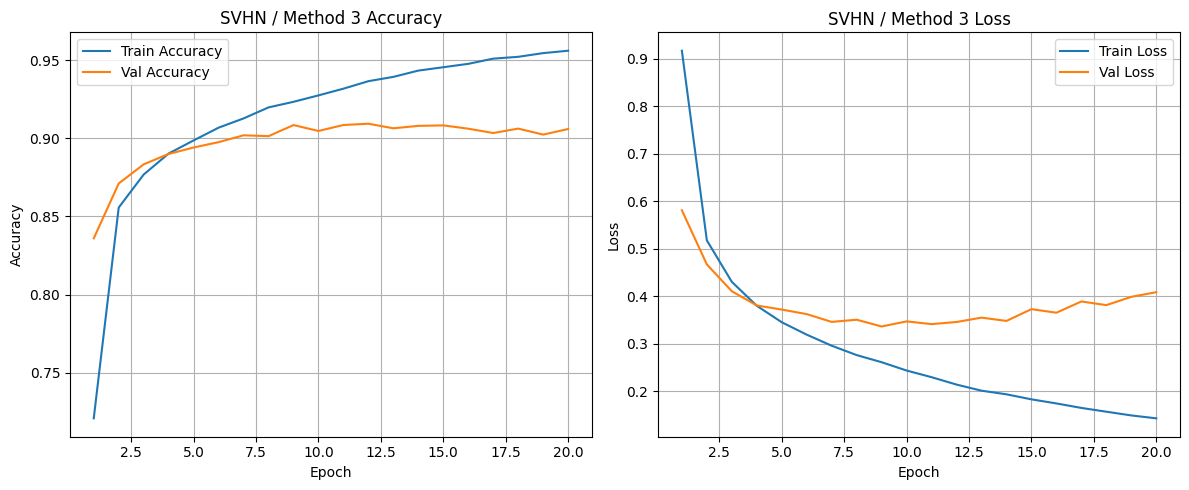



SVHN - Method 4
-----------------
Epoch 1/20
1242/1242 - 11s - 9ms/step - accuracy: 0.5653 - loss: 1.3357 - val_accuracy: 0.8035 - val_loss: 0.6837
Epoch 2/20
1242/1242 - 10s - 8ms/step - accuracy: 0.7306 - loss: 0.8869 - val_accuracy: 0.8413 - val_loss: 0.5583
Epoch 3/20
1242/1242 - 9s - 7ms/step - accuracy: 0.7669 - loss: 0.7631 - val_accuracy: 0.8587 - val_loss: 0.4843
Epoch 4/20
1242/1242 - 8s - 7ms/step - accuracy: 0.7935 - loss: 0.6791 - val_accuracy: 0.8688 - val_loss: 0.4512
Epoch 5/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8111 - loss: 0.6196 - val_accuracy: 0.8742 - val_loss: 0.4182
Epoch 6/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8251 - loss: 0.5726 - val_accuracy: 0.8813 - val_loss: 0.4003
Epoch 7/20
1242/1242 - 9s - 7ms/step - accuracy: 0.8323 - loss: 0.5491 - val_accuracy: 0.8855 - val_loss: 0.3922
Epoch 8/20
1242/1242 - 9s - 7ms/step - accuracy: 0.8403 - loss: 0.5264 - val_accuracy: 0.8915 - val_loss: 0.3685
Epoch 9/20
1242/1242 - 8s - 7ms/step - accuracy: 0.8481 - 

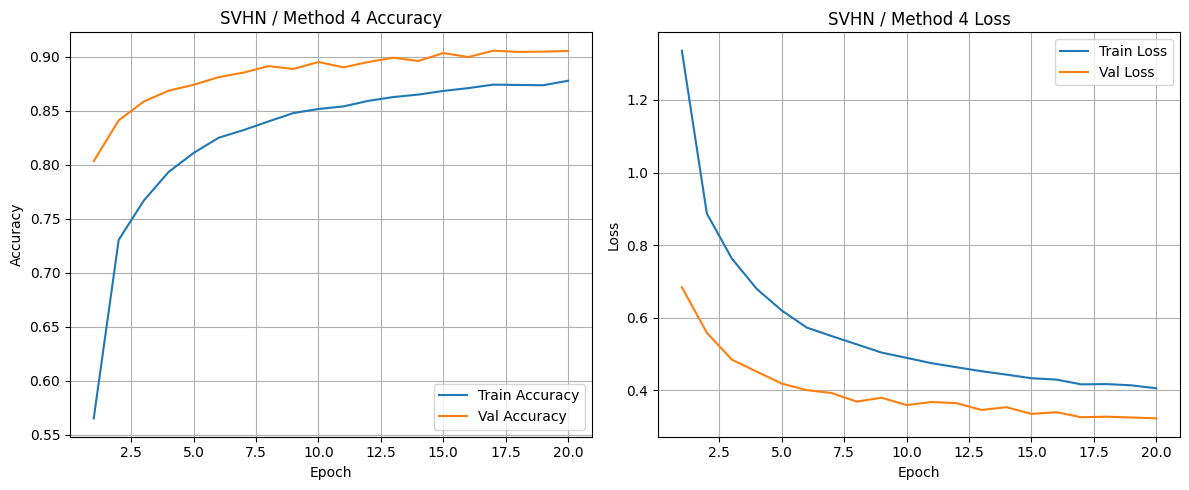



SVHN - Method 5
-----------------
Epoch 1/20
1242/1242 - 9s - 7ms/step - accuracy: 0.6286 - loss: 1.3303 - val_accuracy: 0.8132 - val_loss: 0.7079
Epoch 2/20
1242/1242 - 8s - 6ms/step - accuracy: 0.7958 - loss: 0.9326 - val_accuracy: 0.8589 - val_loss: 0.5560
Epoch 3/20
1242/1242 - 8s - 6ms/step - accuracy: 0.8140 - loss: 0.8630 - val_accuracy: 0.8611 - val_loss: 0.5261
Epoch 4/20
1242/1242 - 8s - 6ms/step - accuracy: 0.8266 - loss: 0.8276 - val_accuracy: 0.8782 - val_loss: 0.4580
Epoch 5/20
1242/1242 - 8s - 6ms/step - accuracy: 0.8360 - loss: 0.8040 - val_accuracy: 0.8824 - val_loss: 0.4535
Epoch 6/20
1242/1242 - 8s - 6ms/step - accuracy: 0.8454 - loss: 0.7784 - val_accuracy: 0.8853 - val_loss: 0.4177
Epoch 7/20
1242/1242 - 8s - 6ms/step - accuracy: 0.8494 - loss: 0.7675 - val_accuracy: 0.8910 - val_loss: 0.4458
Epoch 8/20
1242/1242 - 8s - 6ms/step - accuracy: 0.8530 - loss: 0.7501 - val_accuracy: 0.8923 - val_loss: 0.4082
Epoch 9/20
1242/1242 - 8s - 6ms/step - accuracy: 0.8585 - lo

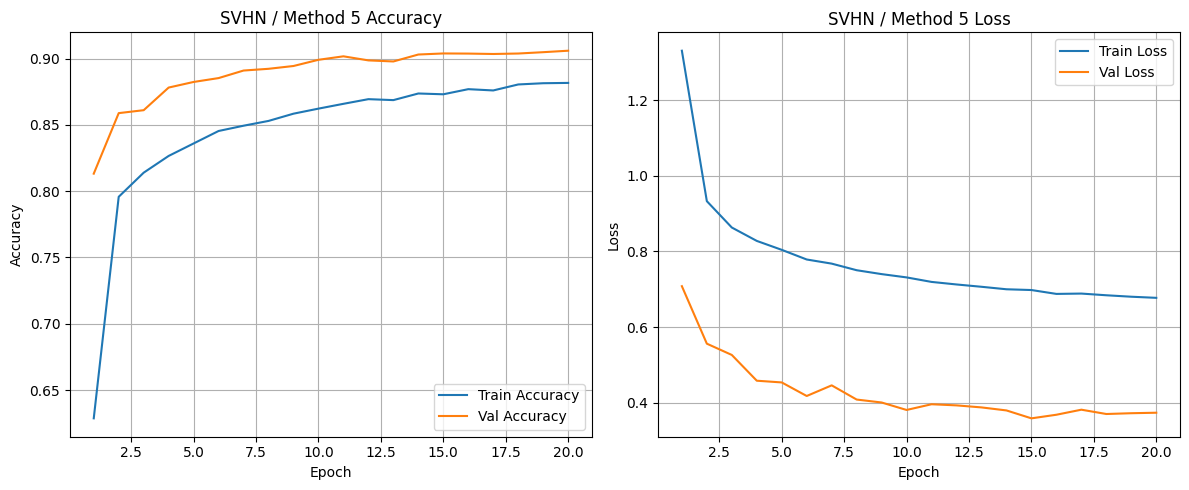



SVHN - Method 6
-----------------
Epoch 1/20
1242/1242 - 9s - 7ms/step - accuracy: 0.4495 - loss: 1.7800 - val_accuracy: 0.7985 - val_loss: 0.7384
Epoch 2/20
1242/1242 - 8s - 6ms/step - accuracy: 0.5957 - loss: 1.4835 - val_accuracy: 0.8501 - val_loss: 0.5781
Epoch 3/20
1242/1242 - 8s - 6ms/step - accuracy: 0.6208 - loss: 1.4252 - val_accuracy: 0.8608 - val_loss: 0.5424
Epoch 4/20
1242/1242 - 8s - 6ms/step - accuracy: 0.6322 - loss: 1.3954 - val_accuracy: 0.8716 - val_loss: 0.5060
Epoch 5/20
1242/1242 - 8s - 6ms/step - accuracy: 0.6431 - loss: 1.3718 - val_accuracy: 0.8779 - val_loss: 0.4845
Epoch 6/20
1242/1242 - 8s - 7ms/step - accuracy: 0.6518 - loss: 1.3520 - val_accuracy: 0.8738 - val_loss: 0.4647
Epoch 7/20
1242/1242 - 8s - 6ms/step - accuracy: 0.6577 - loss: 1.3408 - val_accuracy: 0.8840 - val_loss: 0.4672
Epoch 8/20
1242/1242 - 8s - 6ms/step - accuracy: 0.6631 - loss: 1.3287 - val_accuracy: 0.8910 - val_loss: 0.4430
Epoch 9/20
1242/1242 - 8s - 6ms/step - accuracy: 0.6663 - lo

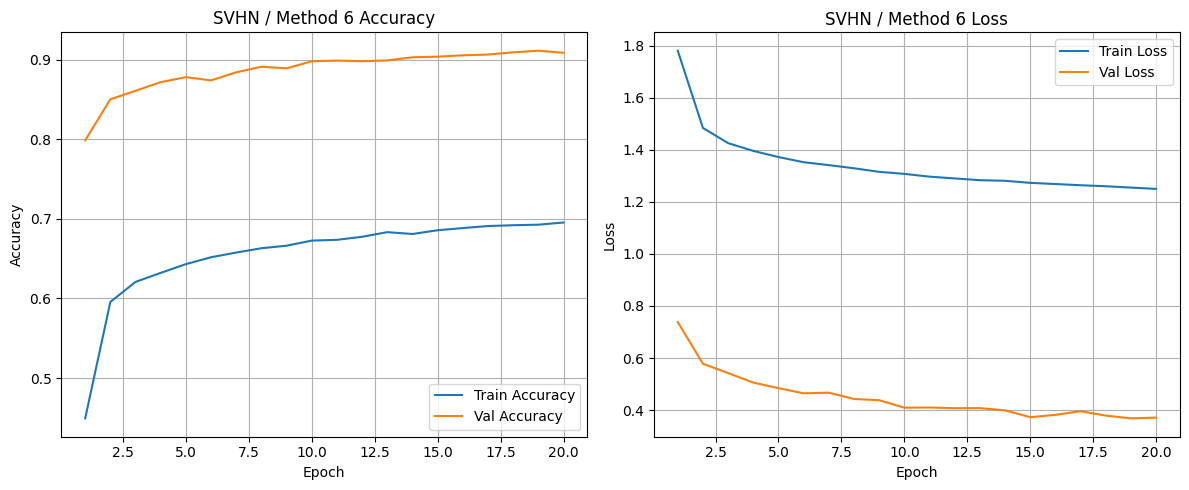



SVHN - Method 7
-----------------
Epoch 1/20
1242/1242 - 16s - 13ms/step - accuracy: 0.4513 - loss: 1.6740 - val_accuracy: 0.7989 - val_loss: 0.7253
Epoch 2/20
1242/1242 - 14s - 11ms/step - accuracy: 0.5759 - loss: 1.3219 - val_accuracy: 0.8312 - val_loss: 0.7211
Epoch 3/20
1242/1242 - 14s - 11ms/step - accuracy: 0.6083 - loss: 1.2184 - val_accuracy: 0.8540 - val_loss: 0.5357
Epoch 4/20
1242/1242 - 14s - 11ms/step - accuracy: 0.6420 - loss: 1.1155 - val_accuracy: 0.8641 - val_loss: 0.4805
Epoch 5/20
1242/1242 - 14s - 11ms/step - accuracy: 0.6646 - loss: 1.0538 - val_accuracy: 0.8769 - val_loss: 0.4392
Epoch 6/20
1242/1242 - 14s - 11ms/step - accuracy: 0.6653 - loss: 1.0428 - val_accuracy: 0.8809 - val_loss: 0.4406
Epoch 7/20
1242/1242 - 14s - 12ms/step - accuracy: 0.6802 - loss: 1.0025 - val_accuracy: 0.8891 - val_loss: 0.3935
Epoch 8/20
1242/1242 - 14s - 11ms/step - accuracy: 0.6911 - loss: 0.9744 - val_accuracy: 0.8694 - val_loss: 0.4534
Epoch 9/20
1242/1242 - 14s - 11ms/step - acc

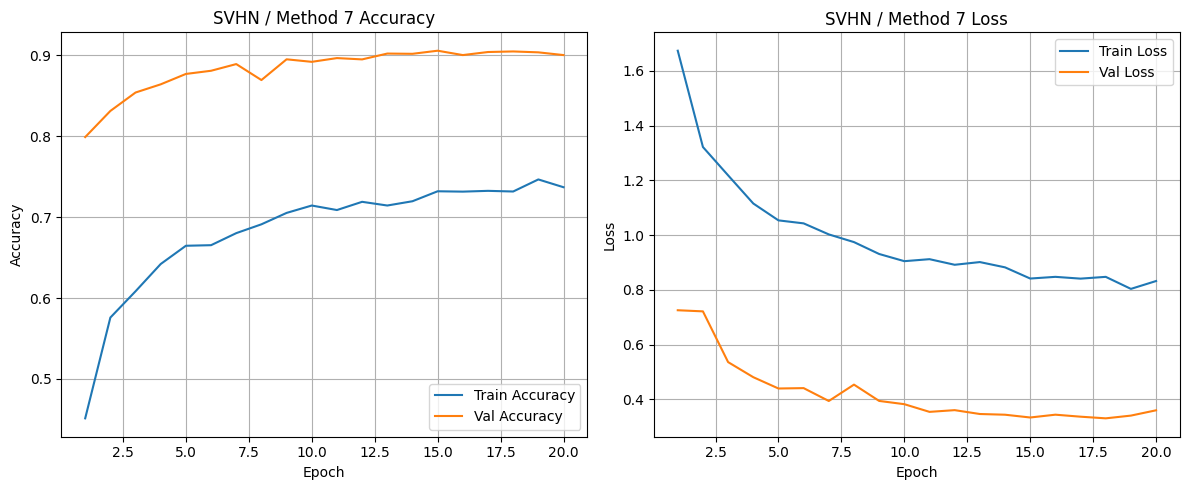


Final accuracy summary (SVHN):
Method 0: train_acc=0.9784, val_acc=0.8969
Method 1: train_acc=0.9126, val_acc=0.8949
Method 2: train_acc=0.9238, val_acc=0.9251
Method 3: train_acc=0.9560, val_acc=0.9059
Method 4: train_acc=0.8780, val_acc=0.9055
Method 5: train_acc=0.8817, val_acc=0.9060
Method 6: train_acc=0.6954, val_acc=0.9085
Method 7: train_acc=0.7369, val_acc=0.9002


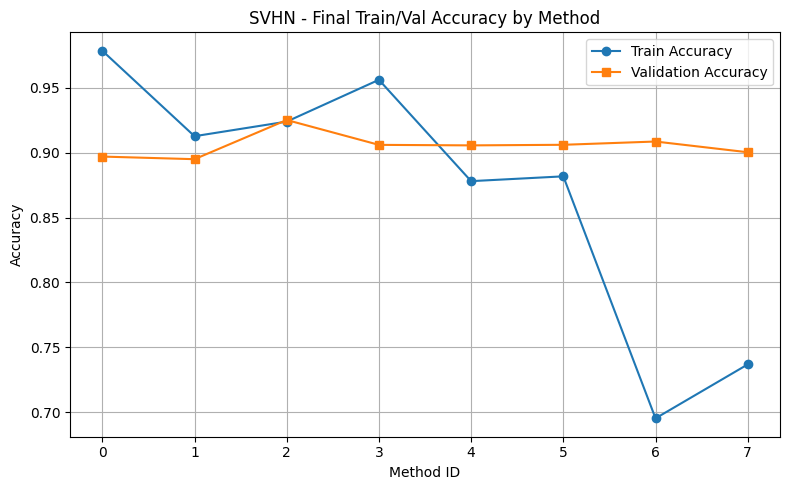

In [3]:
ds = tfds.load("svhn_cropped", split="train+test", as_supervised=True)

images = []
labels = []

for img, lab in tfds.as_numpy(ds):
    images.append(img)
    labels.append(lab)

X = np.stack(images).astype("float32") / 255.0
y = np.array(labels).astype("int64")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (32, 32, 3)
num_classes = 10
is_rgb = True

results = {}

for method_id in range(8):
    print("\n")
    print(f"SVHN - Method {method_id}")
    print("-----------------")

    history, train_acc, val_acc = run_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape,
        num_classes=num_classes,
        method_id=method_id,
        is_rgb=is_rgb
    )

    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"SVHN / Method {method_id}")

print("\nFinal accuracy summary (SVHN):")
for k in range(8):
    ta, va = results[k]
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")

plot_final_summary(results, title="SVHN - Final Train/Val Accuracy by Method")